In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

e:\Projects\AI Text Classifier\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset('sms_spam')
df = pd.DataFrame(dataset['train'])
print(df.shape)
print(df.head())

(5574, 2)
                                                 sms  label
0  Go until jurong point, crazy.. Available only ...      0
1                    Ok lar... Joking wif u oni...\n      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0


In [3]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

label
0    4827
1     747
Name: count, dtype: int64
label
0    0.865985
1    0.134015
Name: proportion, dtype: float64


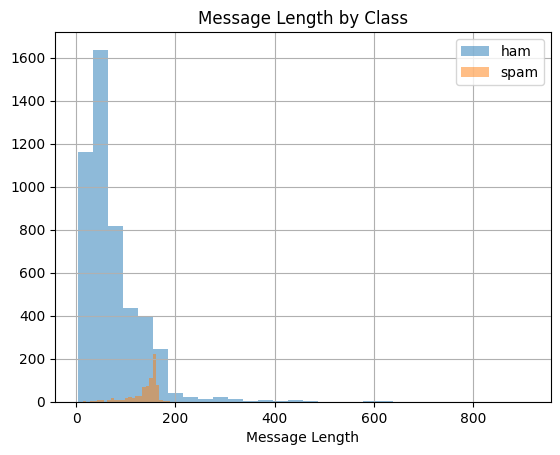

In [4]:
df['length'] = df['sms'].apply(len)
df.groupby('label')['length'].hist(alpha=0.5, bins=30)
plt.xlabel('Message Length')
plt.legend(['ham', 'spam'])
plt.title('Message Length by Class')
plt.show()

In [5]:
print('SPAM samples:')
print(df[df['label']==1]['sms'].head(3).values)
print('\nHAM samples:')
print(df[df['label']==0]['sms'].head(3).values)

SPAM samples:
<ArrowStringArray>
[  'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's\n',
           'FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv\n',
 'WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.\n']
Length: 3, dtype: str

HAM samples:
<ArrowStringArray>
['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n',
                                                                                   'Ok lar... Joking wif u oni...\n',
                                                               'U dun say so early hor... U c already then say...\n']
Length: 3, dtype: str
